In [1]:
import tensorflow as tf
print(tf.reduce_sum(tf.random.normal([1000, 1000])))
print(tf.config.list_physical_devices('GPU'))


2022-11-09 21:47:24.126566: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:937] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero


tf.Tensor(-798.27545, shape=(), dtype=float32)
[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


2022-11-09 21:47:24.127582: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:937] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2022-11-09 21:47:24.424060: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:937] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2022-11-09 21:47:24.424958: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:937] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2022-11-09 21:47:24.425752: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:937] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2022-11-09 21:47:24.426508: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:937] successful NUMA node read from S

In [2]:

print(tf.config.list_physical_devices('GPU'))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pickle
import os
import csv 

import keras
import tensorflow as tf
from keras import backend
from keras.backend import set_session

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Activation, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.layers import Conv2D, MaxPooling2D, UpSampling2D, Dropout, LeakyReLU, Conv2DTranspose, ReLU
from tensorflow.keras.optimizers import Adam
from keras.layers import Reshape
from keras import layers
import datetime

from keras import initializers


config = tf.compat.v1.ConfigProto()
config.gpu_options.per_process_gpu_memory_fraction = 0.9 # fraction of memory
config.gpu_options.visible_device_list = "0"

set_session(tf.compat.v1.Session(config=config))

2022-11-09 21:47:31.362589: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:937] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2022-11-09 21:47:31.363828: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:937] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2022-11-09 21:47:31.364534: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:937] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2022-11-09 21:47:31.365303: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:937] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2022-11-09 21:47:31.366000: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:937] successful NUMA node read from S

In [4]:
path = '../input/occlude-face-image'
xname = '1_half_face_occluded.pickle'
yname = '1_half_face_labels.pickle'
pickle_in = open(os.path.join(path,xname),"rb")
x = pickle.load(pickle_in)

pickle_in = open(os.path.join(path,yname),"rb")
y = pickle.load(pickle_in)

print(x.shape)
print(y.shape)

(4471, 200, 200, 1)
(4471, 200, 200, 1)


In [5]:
fields = ["Gan Loss", "Disc loss", "Gen Loss" , "Test Gan Loss", "Test Disc Loss"]
rows = []
print(rows)

[]


(4471, 128, 128, 1)
(4471, 128, 128, 1)


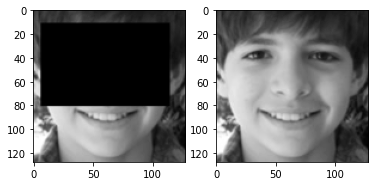

In [6]:
#I use this because with 200,200 images, I exceed GPU memory.

from skimage.transform import resize
x = resize(x, (len(x),128 ,128,1), anti_aliasing=False)
y = resize(y, (len(y),128 ,128,1), anti_aliasing=False)

# Print the shape after resize
print(x.shape)
print(y.shape)

#Draw the image to be sure occluded image is the same as the ground truth one
fig=plt.figure(figsize=(6, 6))
fig.add_subplot(1, 2, 1)
plt.imshow(x[3,:,:,0],cmap="gray")
fig.add_subplot(1, 2, 2)
plt.imshow(y[3,:,:,0],cmap="gray")

In [7]:
#I print pixel values to be sure occluded and ground truth images are aligned
print(x[0,0:5,0:5,0])
print(y[0,0:5,0:5,0])

[[0.24939491 0.23825827 0.27104013 0.30754442 0.29100031]
 [0.24472656 0.26824831 0.30148208 0.32007889 0.31814108]
 [0.23182062 0.2844401  0.31668581 0.32921645 0.34226792]
 [0.27890242 0.31342295 0.3276731  0.32560892 0.33008961]
 [0.25456112 0.2747549  0.29811581 0.31524586 0.32365196]]
[[0.24939491 0.23825827 0.27104013 0.30754442 0.29100031]
 [0.24472656 0.26824831 0.30148208 0.32007889 0.31814108]
 [0.23182062 0.2844401  0.31668581 0.32921645 0.34226792]
 [0.27890242 0.31342295 0.3276731  0.32560892 0.33008961]
 [0.25456112 0.2747549  0.29811581 0.31524586 0.32365196]]


In [8]:
#Here is the function to create a generator. I also use the function and create a generator in the same cell.
def creategen():
  generator = Sequential()


  generator.add(Conv2D(64, (5,5) , strides = (2,2), input_shape = x.shape[1:] , padding = "SAME",kernel_initializer = 'random_normal'))
  generator.add(BatchNormalization())
  generator.add(ReLU())  
  generator.add(Dropout(0.3))


  generator.add(Conv2D(128, (5,5) ,  strides = (2,2),padding = "SAME",kernel_initializer = 'random_normal'))
  generator.add(BatchNormalization())
  generator.add(ReLU())  
  generator.add(Dropout(0.3))

  
  generator.add(Conv2D(256, (5,5) ,  strides = (2,2), padding = "SAME",kernel_initializer = 'random_normal'))
  generator.add(BatchNormalization())
  generator.add(ReLU())  
  generator.add(Dropout(0.3))

  # I would use these if there was a bottleneck in the network.
  #generator.add(Flatten())
  
  #generator.add(Dense(64)) 
  #generator.add(BatchNormalization())
  #generator.add(ReLU(alpha=0.2))
  
  #generator.add(Dense(8*8*128)) 
  #generator.add(BatchNormalization())
  #generator.add(ReLU(alpha=0.2))
  
  #generator.add(layers.Reshape((8,8,128)))


  generator.add(Conv2DTranspose(128, (5, 5), strides=(2, 2), padding='same', use_bias=False))
  generator.add(BatchNormalization())
  generator.add(ReLU())
  
  generator.add(Conv2DTranspose(64, (5, 5), strides=(2, 2), padding='same', use_bias=False))
  generator.add(BatchNormalization())
  generator.add(ReLU())
  
  generator.add(Conv2DTranspose(1, (5, 5), strides=(2, 2), padding='same', use_bias=False, activation = "tanh"))
  

  return generator

generator = creategen()



In [9]:
#Here is the function to create a discriminator. 
#I also use the function and create a discriminator in the same cell.
def createdisc():
  discriminator = Sequential()

  discriminator.add(Conv2D(64, (5,5) , strides = (2,2), input_shape = x.shape[1:] , padding = "SAME",kernel_initializer = 'random_normal'))
  discriminator.add(BatchNormalization())
  discriminator.add(LeakyReLU(alpha=0.2))  
  discriminator.add(Dropout(0.3))


  discriminator.add(Conv2D(128, (5,5) ,  strides = (2,2),padding = "SAME",kernel_initializer = 'random_normal'))
  discriminator.add(BatchNormalization())
  discriminator.add(LeakyReLU(alpha=0.2))  
  discriminator.add(Dropout(0.3))

  
  discriminator.add(Conv2D(256, (5,5) ,  strides = (2,2), padding = "SAME",kernel_initializer = 'random_normal'))
  discriminator.add(BatchNormalization())
  discriminator.add(LeakyReLU(alpha=0.2))  
  discriminator.add(Dropout(0.3))

  
  discriminator.add(Flatten())
  discriminator.add(Dense(1))
  
  return discriminator


discriminator = createdisc()



In [10]:
generator.summary()

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv2d (Conv2D)              (None, 64, 64, 64)        1664      
_________________________________________________________________
batch_normalization (BatchNo (None, 64, 64, 64)        256       
_________________________________________________________________
re_lu (ReLU)                 (None, 64, 64, 64)        0         
_________________________________________________________________
dropout (Dropout)            (None, 64, 64, 64)        0         
_________________________________________________________________
conv2d_1 (Conv2D)            (None, 32, 32, 128)       204928    
_________________________________________________________________
batch_normalization_1 (Batch (None, 32, 32, 128)       512       
_________________________________________________________________
re_lu_1 (ReLU)               (None, 32, 32, 128)       0

In [11]:
# Learning rate of discriminator is advised to be the double of the generator. 
# I train the generator two times in each step of training. First is with Gan loss, second is with L2 loss.
# That is why I use x4 learning rate in discriminator.

opt_disc = Adam(lr=0.00004)
discriminator.trainable = True
discriminator.compile(loss = "binary_crossentropy", optimizer = opt_disc)
discriminator.summary()

Model: "sequential_1"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv2d_3 (Conv2D)            (None, 64, 64, 64)        1664      
_________________________________________________________________
batch_normalization_5 (Batch (None, 64, 64, 64)        256       
_________________________________________________________________
leaky_re_lu (LeakyReLU)      (None, 64, 64, 64)        0         
_________________________________________________________________
dropout_3 (Dropout)          (None, 64, 64, 64)        0         
_________________________________________________________________
conv2d_4 (Conv2D)            (None, 32, 32, 128)       204928    
_________________________________________________________________
batch_normalization_6 (Batch (None, 32, 32, 128)       512       
_________________________________________________________________
leaky_re_lu_1 (LeakyReLU)    (None, 32, 32, 128)      

/opt/conda/lib/python3.7/site-packages/keras/optimizer_v2/optimizer_v2.py:356: UserWarning: The `lr` argument is deprecated, use `learning_rate` instead.
  "The `lr` argument is deprecated, use `learning_rate` instead.")


In [12]:
opt_gen = Adam(lr=0.00001)
generator.compile(loss='mean_squared_error', optimizer = opt_gen)
generator.summary()

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv2d (Conv2D)              (None, 64, 64, 64)        1664      
_________________________________________________________________
batch_normalization (BatchNo (None, 64, 64, 64)        256       
_________________________________________________________________
re_lu (ReLU)                 (None, 64, 64, 64)        0         
_________________________________________________________________
dropout (Dropout)            (None, 64, 64, 64)        0         
_________________________________________________________________
conv2d_1 (Conv2D)            (None, 32, 32, 128)       204928    
_________________________________________________________________
batch_normalization_1 (Batch (None, 32, 32, 128)       512       
_________________________________________________________________
re_lu_1 (ReLU)               (None, 32, 32, 128)       0

In [13]:
#Here is the function to create a GAN model. I also use the function and create GAN model in the same cell.

def creategan(generator,discriminator):
  gan = Sequential()
  gan.add(generator)
  discriminator.trainable = False
  gan.add(discriminator)
  return(gan)

gan = creategan(generator,discriminator)

In [14]:
opt_gan = Adam(lr=0.00001)
gan.compile(loss = "binary_crossentropy", optimizer = opt_gan)
gan.summary()

Model: "sequential_2"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
sequential (Sequential)      (None, 128, 128, 1)       2054208   
_________________________________________________________________
sequential_1 (Sequential)    (None, 1)                 1093377   
Total params: 3,147,585
Trainable params: 2,052,928
Non-trainable params: 1,094,657
_________________________________________________________________


In [15]:
# This is to save models. It saves both the architectures and the weights.
# While loading the model, you will only need weights since you declared the architecture in the previous cells.

def save_models(gan,discriminator,generator,path,epoch):
  datenow = str(datetime.datetime.now().strftime('%m-%d-%H:%M'))
  gan.save_weights(os.path.join(path,"{0}_wgan_{1}.h5".format(epoch,datenow)))
  gan.save(os.path.join(path,"{0}_mgan_{1}.h5".format(epoch,datenow)))


  discriminator.save_weights(os.path.join(path,"{0}_wd_{1}.h5".format(epoch,datenow)))
  discriminator.save(os.path.join(path,"{0}_md_{1}.h5".format(epoch,datenow)))


  generator.save_weights(os.path.join(path,"{0}_wg_{1}.h5".format(epoch,datenow)))
  generator.save(os.path.join(path,"{0}_mg_{1}.h5".format(epoch,datenow)))
  

  

In [16]:
def test(x,y):
  gan_inp_t = x  
  gan_label_t = np.ones([len(gan_inp_t)])
  gan_predict_t = None
  
  disc_inp_t = None


  disc_label_t = np.zeros([len(gan_inp_t)*2])
  disc_label_t[len(gan_inp_t):] = 1
  
  disc_predict_t = None
  

  gen_predict_t = generator.predict(gan_inp_t)


  disc_inp_t = np.concatenate((gen_predict_t,y), axis = 0)
  disc_predict_t = discriminator.predict(disc_inp_t)

  d_loss_t = discriminator.test_on_batch(disc_inp_t,disc_label_t)

  gan_loss_t = gan.test_on_batch(gan_inp_t,gan_label_t)
  
  return (gan_loss_t, d_loss_t)

In [17]:
# I use isolated mini batches to slow down discriminator:
# I also use smooth/noisy labels proposed by Salimans et al 2016
# Reference: https://github.com/soumith/ganhacks



def train(x,y, nepoch, model_save_path = "./"):

  gen_predict = None
  
  #Initialize the inputs and the labels.
  gan_inp = x  #occludeded image
  gan_label = np.ones(64)
  gan_predict = None
  
  disc_inp = None


  disc_label = np.zeros(64*2)
  disc_label[64:] = 1
  
  disc_predict = None
  

  sess = tf.compat.v1.Session()

  

  for epoch in range(nepoch):

    for batch_ctr in range(65):

      #Generator makes a prediction
      gen_predict = generator.predict(gan_inp[batch_ctr*64:(batch_ctr+1)*64])


      #Minibatch isolation and label smoothing is done here:
      
      if(epoch%2==0):
        disc_inp = gen_predict
        #disc_label = np.zeros(64) //// I would use this line if there was no noisy labels.
        disc_label = np.random.normal(loc=0, scale=0.10, size=64)
      else:
        disc_inp = y[batch_ctr*64:(batch_ctr+1)*64]
        #disc_label = np.ones(64)  //// I would use this line if there was no noisy labels.
        disc_label = np.random.normal(loc=1, scale=0.10, size=64)


        
      #Initialize a label variable for generator to use it in training.  
      gen_label = y[batch_ctr*64:(batch_ctr+1)*64]
      
      
      #Do one training step. Also assign the losses to variables. We will print them.
      d_loss = discriminator.train_on_batch(disc_inp,disc_label)


      gan_loss = gan.train_on_batch(gan_inp[batch_ctr*64:(batch_ctr+1)*64],
                                    gan_label) #minmax func

      gen_loss = generator.train_on_batch(gan_inp[batch_ctr*64:(batch_ctr+1)*64],gen_label)
      
    
    
    if epoch == nepoch - 1:
      save_models(gan,discriminator,generator, model_save_path,epoch+1)  
      print("MODEL SAVED")
      
    
    # Test images are the images after the 4160th image. It makes 311 test images.
    (tgan,tdisc)= test(x[4160:],y[4160:])
    
    rows.append([gan_loss,d_loss,gen_loss,tgan,tdisc])
    print("Epoch: {2} Gan Loss: {0}       Disc Loss: {1}        Gen Loss: {3}".format(gan_loss,d_loss,epoch+1,gen_loss))
    print("Epoch: {2} Test Gan Loss: {0}  Test Disc Loss: {1} \n\n\n".format(tgan,tdisc,epoch+1))

In [18]:
# Checking lengths of the input and ground truth arrays. Also checking if normalization is done.
print(len(x),len(y))
print(x.max(),x.min())
print(y.max(),y.min())

4471 4471
1.0 0.0
1.0 0.0


In [19]:
# Use this cell if you have loaded and viewed the results, and want to train further.
# If you start the model from beginning, using above cells where I declare 
# generator architecture, discriminator architecture etc. , you don't need to use this cell since
# I already compile the models in above cells.


# Learning rate of discriminator is advised to be the double of the generator. 
# I train the generator two times in each step of training. First is with Gan loss, second is with L2 loss.
# That is why I use x4 learning rate in discriminator.

"""opt_disc = Adam(lr=0.00004)
discriminator.trainable = True
discriminator.compile(loss = "binary_crossentropy", optimizer = opt_disc)
discriminator.summary()

opt_gen = Adam(lr=0.00001)
generator.compile(loss='mean_squared_error', optimizer = opt_gen)
generator.summary()

opt_gan = Adam(lr=0.00001)
gan.compile(loss = "binary_crossentropy", optimizer = opt_gan)
gan.summary()"""

'opt_disc = Adam(lr=0.00004)\ndiscriminator.trainable = True\ndiscriminator.compile(loss = "binary_crossentropy", optimizer = opt_disc)\ndiscriminator.summary()\n\nopt_gen = Adam(lr=0.00001)\ngenerator.compile(loss=\'mean_squared_error\', optimizer = opt_gen)\ngenerator.summary()\n\nopt_gan = Adam(lr=0.00001)\ngan.compile(loss = "binary_crossentropy", optimizer = opt_gan)\ngan.summary()'

In [20]:
# # #print(os.path.join(model_path,"{0}_wg_11-04-11_28.h5".format(epoch)))

model_path = "../input/250-epochs-weight"

epoch = 250

#generator = creategen()
generator.load_weights(os.path.join(model_path,"{0}_wg_11-09-20_34.h5".format(epoch)))
#discriminator = createdisc()
discriminator.load_weights(os.path.join(model_path,"{0}_wd_11-09-20_34.h5".format(epoch)))

#gan = creategan(generator,discriminator)
gan.load_weights(os.path.join(model_path,"{0}_wgan_11-09-20_34.h5".format(epoch)))
print("250 Epoch weight loaded")

250 Epoch weight loaded


In [21]:
# To train, don't forget to:
# -compile the models
# - run the necessary cells to declare the necessary functions such as "train" and "save_models" and "test"

#If you train models from beginning, just run the cells of the notebook in order.

#If you want to further train loaded models, use the previous cell to compile models.

model_save_path = './'
batch_size = 64
train(x,y,1000,model_save_path)


2022-11-09 21:48:08.980708: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:937] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2022-11-09 21:48:08.982308: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:937] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2022-11-09 21:48:08.983975: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:937] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2022-11-09 21:48:08.984853: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:937] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2022-11-09 21:48:08.985944: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:937] successful NUMA node read from S

Epoch: 1 Gan Loss: 15.424948692321777       Disc Loss: -0.03923964127898216        Gen Loss: 0.007997522130608559
Epoch: 1 Test Gan Loss: 15.424947738647461  Test Disc Loss: 7.7124738693237305 



Epoch: 2 Gan Loss: 15.424948692321777       Disc Loss: 15.306229591369629        Gen Loss: 0.008140629157423973
Epoch: 2 Test Gan Loss: 15.424947738647461  Test Disc Loss: 7.7124738693237305 



Epoch: 3 Gan Loss: 15.424948692321777       Disc Loss: -0.03466399013996124        Gen Loss: 0.008108044974505901
Epoch: 3 Test Gan Loss: 15.424947738647461  Test Disc Loss: 7.7124738693237305 



Epoch: 4 Gan Loss: 15.424948692321777       Disc Loss: 15.92647647857666        Gen Loss: 0.008062652312219143
Epoch: 4 Test Gan Loss: 15.424947738647461  Test Disc Loss: 7.7124738693237305 



Epoch: 5 Gan Loss: 15.424948692321777       Disc Loss: -0.2194681465625763        Gen Loss: 0.008108540438115597
Epoch: 5 Test Gan Loss: 15.424947738647461  Test Disc Loss: 7.7124738693237305 



Epoch: 6 Gan Loss: 15

In [22]:
filename = "loss.csv"
    
# # writing to csv file 
with open(filename, 'w', newline='') as csvfile: 
#     # creating a csv writer object 
    csvwriter = csv.writer(csvfile) 
        
#     # writing the fields 
    csvwriter.writerow(fields) 
        
#     # writing the data rows 
    csvwriter.writerows(rows)

In [23]:
# # #print(os.path.join(model_path,"{0}_wg_11-04-11_28.h5".format(epoch)))

# model_path = "../input/../input/250-epochs-weight"

# epoch = 250

# #generator = creategen()
# generator.load_weights(os.path.join(model_path,"{0}_wg_11-09-20_34.h5".format(epoch)))
# #discriminator = createdisc()
# discriminator.load_weights(os.path.join(model_path,"{0}_wd_11-09-20_34.h5".format(epoch)))

# #gan = creategan(generator,discriminator)
# gan.load_weights(os.path.join(model_path,"{0}_wgan_11-09-20_34.h5".format(epoch)))

In [24]:
#Making predictions and drawing them.
#First row: Occluded images
#Second row: Ground Truth images
#Third row: Predictions

# import datetime
# plot_path = "./"

# a = 4160
# b = 4170
# pred=generator.predict(x[a:b])

# fig = plt.figure(figsize = (20,10))
# for ctr in range(10):
#   fig.add_subplot(3,10,ctr+1)
#   plt.imshow(np.reshape(x[a + ctr],(128,128)),  cmap = "gray")

  

# for ctr in range(10):
#   fig.add_subplot(3,10,(10 + ctr + 1))
#   plt.imshow(np.reshape(y[a + ctr]/255,(128,128)),  cmap = "gray")  


# for ctr in range(10):
#   fig.add_subplot(3,10,(20 + ctr + 1))
#   plt.imshow(np.reshape(pred[ctr],(128, 128)),  cmap = "gray")
  
# plt.savefig(os.path.join(plot_path,str(datetime.datetime.now().strftime('%m-%d-%H:%M'))))

In [25]:
# # #print(os.path.join(model_path,"{0}_wg_11-04-11_28.h5".format(epoch)))

# model_path = "../input/weight-2500"

# epoch = 2500

# #generator = creategen()
# generator.load_weights(os.path.join(model_path,"{0}_wg_11-09-20_34.h5".format(epoch)))
# #discriminator = createdisc()
# discriminator.load_weights(os.path.join(model_path,"{0}_wd_11-09-20_34.h5".format(epoch)))

# #gan = creategan(generator,discriminator)
# gan.load_weights(os.path.join(model_path,"{0}_wgan_11-09-20_34.h5".format(epoch)))

In [26]:
# import cv2
# import matplotlib.image as mpimg
# img = mpimg.imread('../input/img245556/4.jpg')
# img = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
# img.shape
# plt.imshow(img)
# from skimage.transform import resize

# img = resize(img, (128 , 128), anti_aliasing=False)
# plt.imshow(img , cmap = 'gray')

In [27]:
# import datetime
# plot_path = "./"
# img = np.expand_dims(img, axis=-1)
# print(img.shape)

In [28]:
# img = np.expand_dims(img, axis=0)
# print(img.shape)
# pred = generator.predict(img)
# print(pred.shape)
# plt.imshow(np.reshape(pred, (128,128)), cmap = "gray")